# Mathematical Engineering — Financial Engineering, FY 2025-2026

## Buy Side, Lab 4b — Risk-Based Allocation Strategies

This notebook implements and analyses risk-based allocation strategies on the Euro Stoxx 50 universe with monthly rebalancing and a 2-year rolling estimation window.

**Outline** 

0. Setup & rolling estimators
1. Part I — Equal Risk Contribution (ERC)
2. Part II — Hierarchical Risk Parity (HRP):
   1. Detoning intuition
   2. Cluster stability across rebalances (Rand index)
   3. Sensitivity to clustering choice and to the volatility allocation scheme
3. Part III — Connecting the dots: ERC vs HRP head-to-head and the role of shrinkage


## 0. Setup


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.metrics import rand_score

from utilities.backtest import backtest, portfolio_returns
from utilities.covariance_utilities import (
    prepare_rolling_estimation_window,
    covariance_to_correlation,
    risk_contribution,
)
from utilities.hierarchical_clustering import hierarchical_clustering
from utilities.hierarchical_risk_parity import (
    correlation_to_hrp_distance,
    dendrogram_iteration,
    hierarchical_risk_parity,
    recursive_bisection,
)
from utilities.portfolio_optimization import (
    equal_risk_contribution_portfolio,
    inverse_volatility_portfolio,
)
from utilities.principal_component_analysis import (
    detone,
    principal_component_analysis,
)
from utilities.shrinkage import constant_corr_shrinkage, market_factor_shrinkage


In [2]:
# Read prices, compute daily simple returns
data_path = Path("data") 
last_prices = pd.read_csv(
    data_path / "sx5e_underlyings.csv", index_col="Date", parse_dates=True
)
performance = last_prices.pct_change().iloc[1:]

/var/folders/ft/2dlq7x3s64q3m_ls0smrbbyw0000gn/T/ipykernel_12780/2636860690.py:6: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  performance = last_prices.pct_change().iloc[1:]


In [3]:
# Estimation parameters
estimation_window = 252*2  # two year of trading days
min_coverage = 0.95  # asset must have >=95% non-NaN in the window
trading_days = 252

# Rebalance on the last trading day of each month
rebalance_dates = pd.DatetimeIndex(
    performance.groupby(pd.Grouper(freq="ME"))
    .apply(lambda x: x.index[-1] if len(x) > 0 else None)
    .dropna()
    .values
)

## 1. Pre-computation: rolling covariance estimators

For each rebalance date we estimate three covariance matrices on the trailing 2-year window:

- **sample** — plain `cov()`,
- **constant_corr** — Ledoit–Wolf (2003) constant-correlation shrinkage,
- **mkt_factor** — Ledoit–Wolf (2002) single-factor shrinkage with the
  equally-weighted return of the surviving universe used as the market
  proxy.

The asset universe at every rebalance is restricted to names with
≥95% non-missing observations in the window.


In [4]:
covariances = {}  # date -> {estimator_name: cov_df}
universes = {}  # date -> [tickers]

for rebalance_date in rebalance_dates:
    cur_returns, diag = prepare_rolling_estimation_window(
        returns=performance,
        rebalance_date=rebalance_date,
        lookback=estimation_window,
        min_coverage=min_coverage,
        return_diagnostics=True,
    )
    if diag["row_count"] < estimation_window or cur_returns.shape[1] == 0:
        continue

    reb = rebalance_date.to_pydatetime().date()

    # Ticker sopravvissuti al filtro min_coverage
    universes[reb] = list(cur_returns.columns)

    # Proxy di mercato: rendimento equally-weighted dell'universo corrente
    market_proxy = cur_returns.mean(axis=1)

    # Tre stimatori di covarianza sulla finestra corrente
    # Nota: le funzioni di shrinkage restituiscono dizionari → estraggo "shrunk_cov"
    #       Salvo come DataFrame (non .values) perché index/columns servono dopo
    covariances[reb] = {
        "sample":        cur_returns.cov(),
        "constant_corr": constant_corr_shrinkage(cur_returns)["shrunk_cov"],
        "mkt_factor":    market_factor_shrinkage(cur_returns, market_proxy)["shrunk_cov"],
    }


all_dates = sorted(covariances.keys())

## Part I — Equal Risk Contribution (ERC)


### 1.b Sanity check: Risk contribution dispersion & IV ≡ ERC under a diagonal Σ


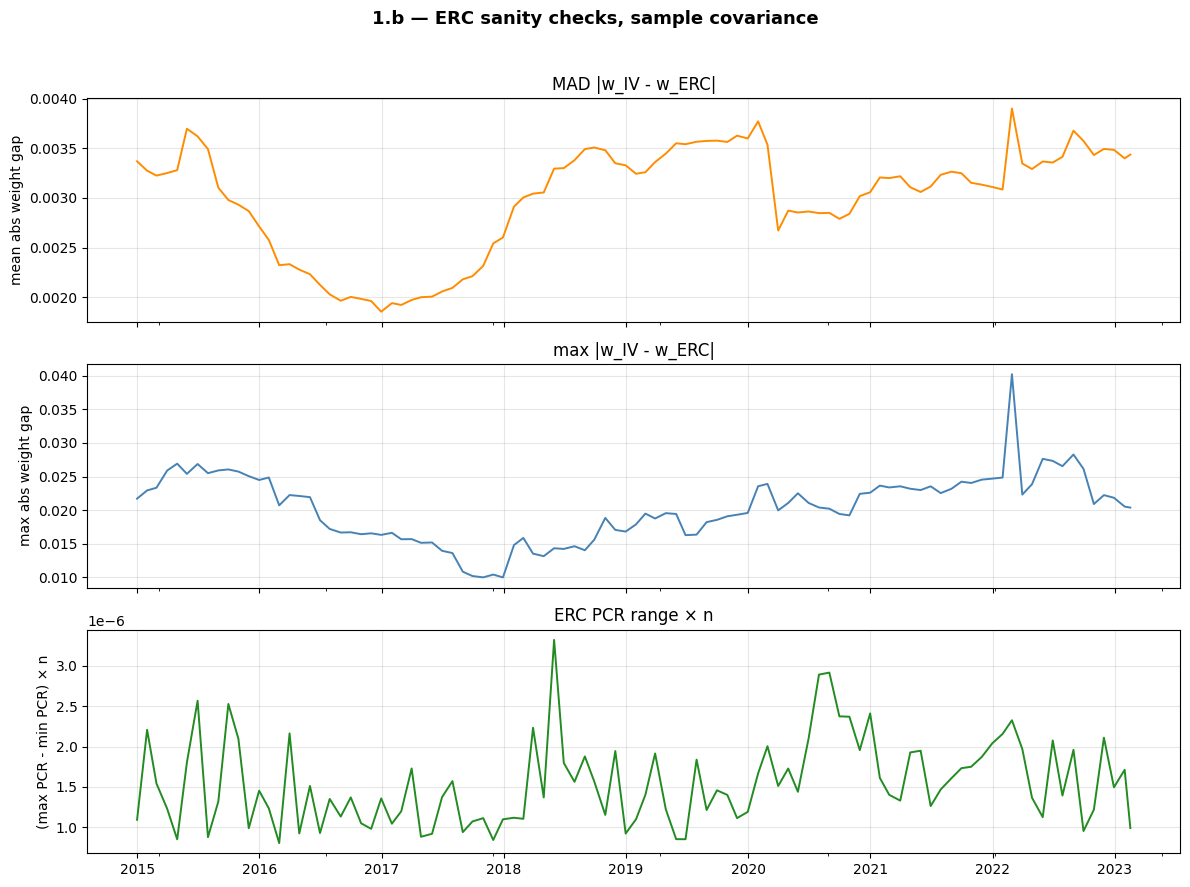

1.b ERC sanity checks — sample covariance
MAD |w_IV - w_ERC|       — mean: 0.002996   max: 0.003901
max |w_IV - w_ERC|       — mean: 0.020326   max: 0.040218
ERC PCR range × n        — mean: 1.54e-06   max: 3.32e-06


In [5]:
# 1.b  ERC sanity check: IV vs ERC and PCR dispersion
import matplotlib.dates as mdates

def percentage_risk_contributions(weights, covariance):
    weights = np.asarray(weights)
    covariance = np.asarray(covariance)

    marginal_contrib = covariance @ weights
    portfolio_var = weights @ marginal_contrib

    pcr = weights * marginal_contrib / portfolio_var
    return pcr


iv_erc_mad = {}
iv_erc_max_gap = {}
erc_normalized_range = {}

for date in all_dates:
    cov = covariances[date]["sample"].values

    w_iv = inverse_volatility_portfolio(cov)
    w_erc = equal_risk_contribution_portfolio(cov)

    pcr = percentage_risk_contributions(w_erc, cov)
    n = len(pcr)

    # Differenza MEDIA assoluta tra pesi IV ed ERC
    iv_erc_mad[date] = float(np.mean(np.abs(w_iv - w_erc)))

    # Differenza MASSIMA assoluta tra pesi IV ed ERC
    iv_erc_max_gap[date] = float(np.max(np.abs(w_iv - w_erc)))

    # Dispersione normalizzata dei percentage risk contributions
    erc_normalized_range[date] = float((pcr.max() - pcr.min()) * n)


iv_erc_mad = pd.Series(iv_erc_mad).sort_index()
iv_erc_max_gap = pd.Series(iv_erc_max_gap).sort_index()
erc_normalized_range = pd.Series(erc_normalized_range).sort_index()


# Plot
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

fig.suptitle(
    "1.b — ERC sanity checks, sample covariance",
    fontsize=13,
    fontweight="bold"
)

iv_erc_mad.plot(ax=axes[0], color="darkorange", lw=1.4)
axes[0].set_title("MAD |w_IV - w_ERC|")
axes[0].set_ylabel("mean abs weight gap")
axes[0].grid(True, alpha=0.3)

iv_erc_max_gap.plot(ax=axes[1], color="steelblue", lw=1.4)
axes[1].set_title("max |w_IV - w_ERC|")
axes[1].set_ylabel("max abs weight gap")
axes[1].grid(True, alpha=0.3)

erc_normalized_range.plot(ax=axes[2], color="forestgreen", lw=1.4)
axes[2].set_title("ERC PCR range × n")
axes[2].set_ylabel("(max PCR - min PCR) × n")
axes[2].grid(True, alpha=0.3)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("fig_1b_erc_sanity_mad_max_pcr.png", dpi=150, bbox_inches="tight")
plt.show()


# Summary values
print("=" * 75)
print("1.b ERC sanity checks — sample covariance")
print("=" * 75)
print(f"MAD |w_IV - w_ERC|       — mean: {iv_erc_mad.mean():.6f}   max: {iv_erc_mad.max():.6f}")
print(f"max |w_IV - w_ERC|       — mean: {iv_erc_max_gap.mean():.6f}   max: {iv_erc_max_gap.max():.6f}")
print(f"ERC PCR range × n        — mean: {erc_normalized_range.mean():.2e}   max: {erc_normalized_range.max():.2e}")
print("=" * 75)

### 1.c ERC backtest across the three covariance estimators


Riepilogo ERC backtest — full sample
Estimatore                  Ann.Ret%  Ann.Vol%    MaxDD%   MeanTO%
----------------------------------------------------------------------
Sample                          9.05     18.77    -38.40      1.05
Const. Corr. (LW 2003)          9.00     18.92    -38.56      0.95
Mkt Factor (LW 2002)            9.04     18.76    -38.37      1.05


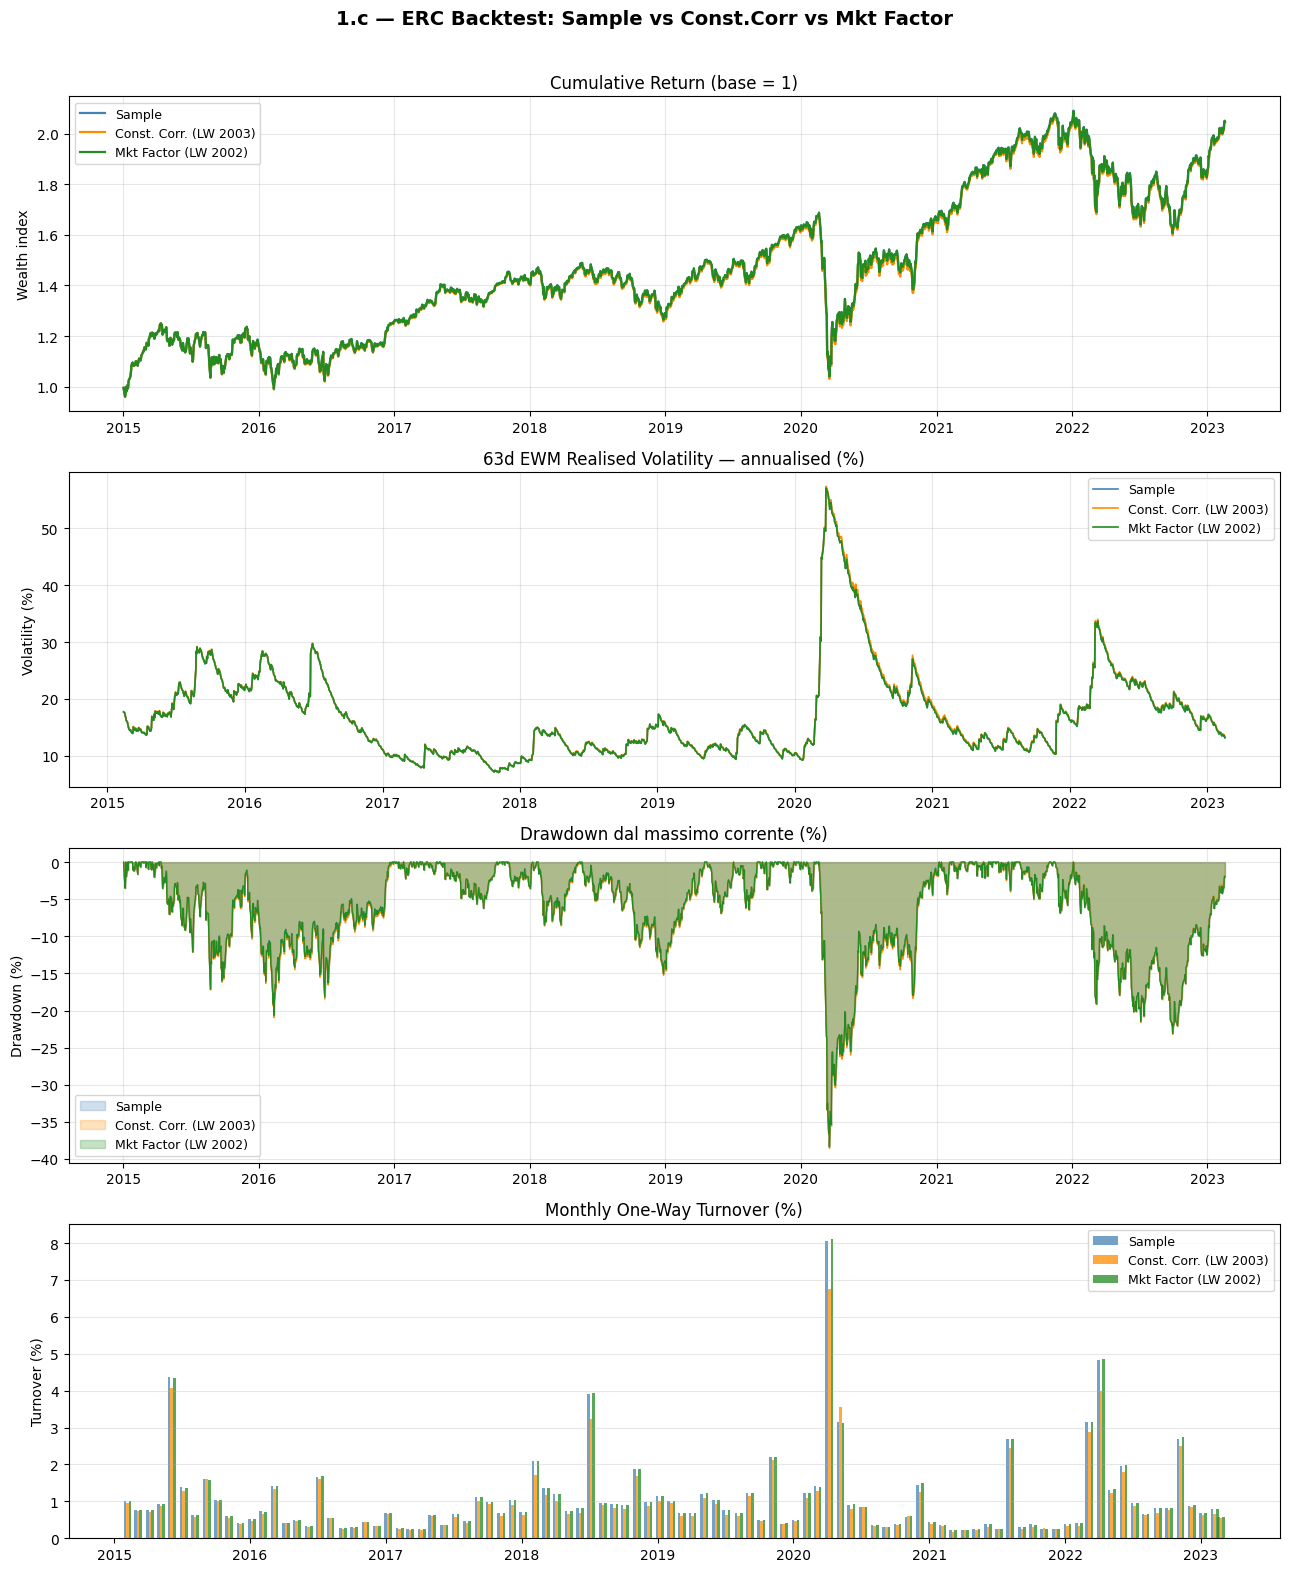

In [6]:
# Compute weights ERC for every rebalance and estimator
erc_portfolios = {"sample": {}, "constant_corr": {}, "mkt_factor": {}}

for reb in all_dates:
    universe = universes[reb]
    for est_name, cov_df in covariances[reb].items():
        # cov_df is a pd.DataFrame; .values produce np.ndarray requested by the validator
        erc_portfolios[est_name][reb] = pd.Series(
            equal_risk_contribution_portfolio(cov_df.values),
            index=universe,
        )

# DataFrame weights (rowns = rebalance dates, columns = tickers)
erc_weights_df = {
    est: pd.DataFrame.from_dict(weights_dict, orient="index")
    for est, weights_dict in erc_portfolios.items()
}

# 1.c.3
def compute_turnover(weights_df: pd.DataFrame) -> pd.Series:
    """
    Monthly one-way turnover: somma |Δw_i| / 2 tra rebalance consecutivi.
    Gli asset non presenti in un certo mese vengono trattati come peso 0.
    """
    w     = weights_df.fillna(0.0)
    delta = w.diff().dropna(how="all")
    return delta.abs().sum(axis=1) / 2.0  # one-way


def compute_drawdown(cum_ret: pd.Series) -> pd.Series:
    """Drawdown (%) dal massimo rolling corrente; sempre ≤ 0."""
    rolling_max = cum_ret.cummax()
    return (cum_ret - rolling_max) / rolling_max


def compute_ewm_vol(ret: pd.Series, span: int = 63, ann: int = 252) -> pd.Series:
    """Volatilità realizzata EWM a 63 giorni, annualizzata."""
    return ret.ewm(span=span, min_periods=span // 2).std() * np.sqrt(ann)


# 1.c.4
ESTIMATORS = ["sample", "constant_corr", "mkt_factor"]
COLORS     = {"sample": "steelblue",
              "constant_corr": "darkorange",
              "mkt_factor": "forestgreen"}
LABELS     = {"sample": "Sample",
              "constant_corr": "Const. Corr. (LW 2003)",
              "mkt_factor": "Mkt Factor (LW 2002)"}

cum_ret_dict = {}
vol_dict     = {}
dd_dict      = {}
to_dict      = {}

for est in ESTIMATORS:
    w_df = erc_weights_df[est]
    daily_ret = portfolio_returns(portfolios=w_df, returns=performance)

    cum_ret_dict[est] = backtest(portfolios=w_df, returns=performance)
    vol_dict[est]     = compute_ewm_vol(daily_ret, span=63)
    dd_dict[est]      = compute_drawdown(cum_ret_dict[est])
    to_dict[est]      = compute_turnover(w_df)

# 1.c.5
print("=" * 70)
print("Riepilogo ERC backtest — full sample")
print("=" * 70)
print(f"{'Estimatore':<26} {'Ann.Ret%':>9} {'Ann.Vol%':>9} "
      f"{'MaxDD%':>9} {'MeanTO%':>9}")
print("-" * 70)

for est in ESTIMATORS:
    daily_ret = portfolio_returns(portfolios=erc_weights_df[est], returns=performance)
    n_days    = len(daily_ret)
    ann_ret   = (1 + daily_ret).prod() ** (252 / n_days) - 1
    ann_vol   = daily_ret.std() * np.sqrt(252)
    max_dd    = dd_dict[est].min()
    mean_to   = to_dict[est].mean()
    print(f"{LABELS[est]:<26} {ann_ret*100:>9.2f} {ann_vol*100:>9.2f} "
          f"{max_dd*100:>9.2f} {mean_to*100:>9.2f}")

print("=" * 70)

# 1.c.6
fig, axes = plt.subplots(4, 1, figsize=(13, 16), sharex=False)
fig.suptitle(
    "1.c — ERC Backtest: Sample vs Const.Corr vs Mkt Factor",
    fontsize=14, fontweight="bold"
)

# Panel 1: Cumulative return
ax = axes[0]
for est in ESTIMATORS:
    ax.plot(cum_ret_dict[est].index, cum_ret_dict[est].values,
            color=COLORS[est], lw=1.6, label=LABELS[est])
ax.set_title("Cumulative Return (base = 1)")
ax.set_ylabel("Wealth index")
ax.legend(framealpha=0.8, fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Panel 2: 63d EWM realised vol
ax = axes[1]
for est in ESTIMATORS:
    ax.plot(vol_dict[est].index, vol_dict[est].values * 100,
            color=COLORS[est], lw=1.2, label=LABELS[est])
ax.set_title("63d EWM Realised Volatility — annualised (%)")
ax.set_ylabel("Volatility (%)")
ax.legend(framealpha=0.8, fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Panel 3: Drawdown
ax = axes[2]
for est in ESTIMATORS:
    ax.fill_between(
        dd_dict[est].index, dd_dict[est].values * 100,
        color=COLORS[est], alpha=0.25, label=LABELS[est]
    )
    ax.plot(dd_dict[est].index, dd_dict[est].values * 100,
            color=COLORS[est], lw=0.9)
ax.set_title("Drawdown dal massimo corrente (%)")
ax.set_ylabel("Drawdown (%)")
ax.legend(framealpha=0.8, fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Panel 4: Monthly one-way turnover
ax = axes[3]
bar_width = 7  # giorni di offset per leggibilità
for i, est in enumerate(ESTIMATORS):
    dates = [
        pd.Timestamp(d) + pd.Timedelta(days=i * bar_width)
        for d in to_dict[est].index
    ]
    ax.bar(dates, to_dict[est].values * 100,
           width=bar_width, color=COLORS[est], alpha=0.75, label=LABELS[est])
ax.set_title("Monthly One-Way Turnover (%)")
ax.set_ylabel("Turnover (%)")
ax.legend(framealpha=0.8, fontsize=9)
ax.grid(True, alpha=0.3, axis="y")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("fig_1c_erc_backtest.png", dpi=150, bbox_inches="tight")
plt.show()

## Part II — Hierarchical Risk Parity (HRP)


### 2.a Detoning — intuition


In [7]:
# Library for heatmaps
import seaborn as sns


last_date = all_dates[-1]
# covariance matrix of the last date
cov_sample = covariances[last_date]["sample"]
# Identity of the assets of the covariance matrix (vector)
tickers = cov_sample.columns


# From the covariance matrix we compute the correlation one
raw_corr = covariance_to_correlation(cov_sample.values)
raw_corr_df = pd.DataFrame(raw_corr, index=tickers, columns=tickers)

# Detoning, remove first PC
detoned_corr = detone(raw_corr, components_num=1)
detoned_corr_df = pd.DataFrame(detoned_corr, index=tickers, columns=tickers)

# HRP distance matrices
raw_dist = correlation_to_hrp_distance(raw_corr_df.values)
detoned_dist = correlation_to_hrp_distance(detoned_corr_df.values)

# Plot Raw Correlation
print(f"--- Analisi per la data {last_date} ---")
print("1. Raw Correlation Dendrogram")
raw_linkage = hierarchical_clustering(
    matrix=pd.DataFrame(raw_dist, index=tickers, columns=tickers),
    linkage_method="ward",
    distance_metric="euclidean",
    plot_dendrogram=True  
)

# Plot: Detoned Correlation
print("2. Detoned Correlation Dendrogram")
detoned_linkage = hierarchical_clustering(
    matrix=pd.DataFrame(detoned_dist, index=tickers, columns=tickers),
    linkage_method="ward",
    distance_metric="euclidean",
    plot_dendrogram=True
)

idx_raw = sch.leaves_list(raw_linkage.values)
idx_detoned = sch.leaves_list(detoned_linkage.values)

# Riordina le matrici di correlazione usando gli indici (Quasi-diagonalizzazione)
quasi_diag_raw = raw_corr_df.iloc[idx_raw, idx_raw]
quasi_diag_detoned = detoned_corr_df.iloc[idx_detoned, idx_detoned]

# Plot matrix almost diagonalized
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Heatmap Raw
sns.heatmap(quasi_diag_raw, cmap='RdYlGn', vmin=-1, vmax=1, ax=axes[0], 
            xticklabels=True, yticklabels=True)
axes[0].set_title('Quasi-diagonalised — Raw correlation')

# Heatmap Detoned
sns.heatmap(quasi_diag_detoned, cmap='RdYlGn', vmin=-1, vmax=1, ax=axes[1], 
            xticklabels=True, yticklabels=True)
axes[1].set_title('Quasi-diagonalised — Detoned correlation')

plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'seaborn'

### 2.b Generic Hierarchical Risk Parity — Parametric Procedure

The hierarchical_risk_parity utility (in utilities/hierarchical_risk_parity.py) is fully parametric across three dimensions:
 
i. Linkage method (linkage_method): controls how the distance between two clusters is defined during agglomerative merging.

single: minimum pairwise distance between members
complete: maximum pairwise distance between members
average: arithmetic mean of pairwise distances (UPGMA)
ward: minimise total within-cluster variance (Ward 1963)

ii. Distance metric (distance_metric): the metric used by scipy.spatial.distance.pdist to compute pairwise distances between the asset distance-profile row-vectors (default euclidean, required by ward).

iii. Volatility-allocation traversal (cluster_traverser): determines how the nested cluster structure is converted into portfolio weights via top-down inverse-variance splits.

recursive_bisection: Lopez de Prado's halving of the dendrogram leaf order, regardless of the actual merge hierarchy. The leaf sequence is split in half recursively; each bisection allocates capital in inverse proportion to the variance of the left and right sub-clusters.
dendrogram_iteration: at every step the active cluster with the largest merge distance (highest-index internal node, since scipy builds nodes in order of increasing distance) is split into its two children, following the actual hierarchy. This respects the dendrogram topology rather than a positional halving.

/Users/marcogretter/Desktop/poli/FINENG/labs/RM/BS-Assignment-4b/utilities/hierarchical_clustering.py:33: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = sch.linkage(
/Users/marcogretter/Desktop/poli/FINENG/labs/RM/BS-Assignment-4b/utilities/hierarchical_clustering.py:33: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = sch.linkage(
/Users/marcogretter/Desktop/poli/FINENG/labs/RM/BS-Assignment-4b/utilities/hierarchical_clustering.py:33: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = sch.linkage(
/Users/marcogretter/Desktop/poli/FINENG/labs/RM/BS-Assignment-4b/utilities/hierarchical_clustering.py:33: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed 

Last rebalance: 2023-02-17  |  n_assets = 50
EW benchmark HHI = 0.0200


,Linkage,Traversal,Detoning,Min w,Max w,Std w,HHI,Sum
0,single,recursive_bisection,False,0.0058,0.0597,0.0134,0.0288,1.0
1,single,recursive_bisection,True,0.0046,0.0601,0.0131,0.0284,1.0
2,single,dendrogram_iteration,False,0.0000,0.4127,0.0692,0.2548,1.0
3,single,dendrogram_iteration,True,0.0000,0.3019,0.0540,0.1628,1.0
4,ward,recursive_bisection,False,0.0058,0.0612,0.0136,0.0290,1.0
5,ward,recursive_bisection,True,0.0045,0.0553,0.0119,0.0269,1.0
6,ward,dendrogram_iteration,False,0.0033,0.0847,0.0217,0.0432,1.0
7,ward,dendrogram_iteration,True,0.0021,0.0676,0.0131,0.0284,1.0
8,complete,recursive_bisection,False,0.0038,0.0649,0.0138,0.0293,1.0
9,complete,recursive_bisection,True,0.0047,0.0554,0.0125,0.0276,1.0


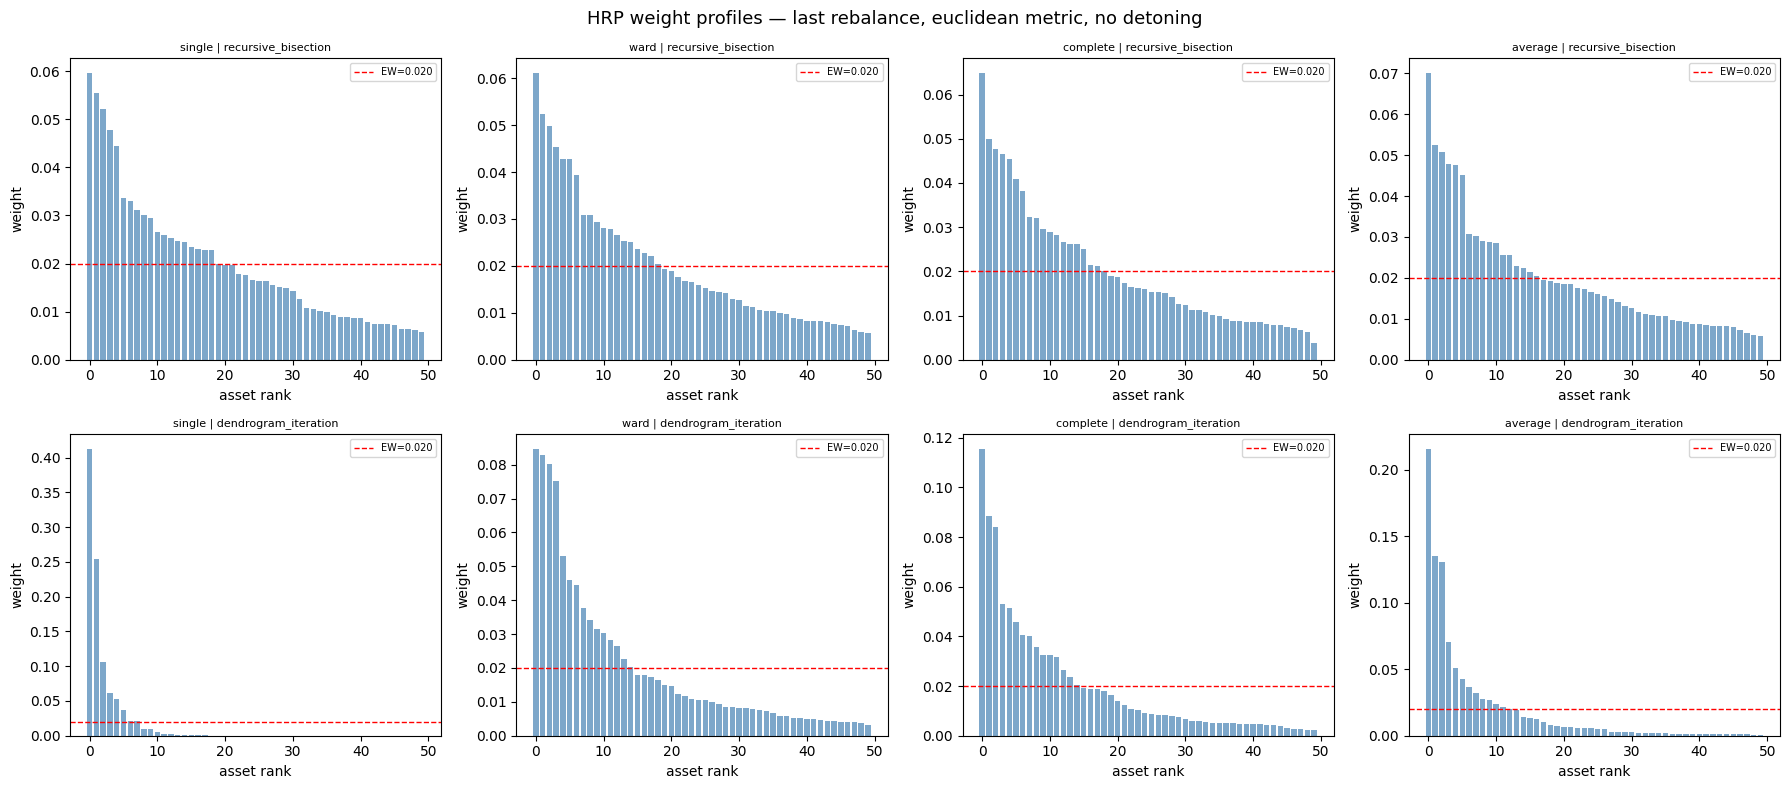

In [ ]:
# ── 2.b  Parametric HRP — all linkage x traverser x detoning combos ─────────
# Demonstrate the three parametric axes on the LAST rebalance date
# using the sample covariance matrix.

last_date = all_dates[-1]
cov_demo  = covariances[last_date]['sample']   # sample cov at last rebalance

LINKAGE_DEMO   = ['single', 'ward', 'complete', 'average']
TRAVERSER_DEMO = {
    'recursive_bisection' : recursive_bisection,   # LdP leaf-order halving
    'dendrogram_iteration': dendrogram_iteration,  # largest-merge-distance split
}
DETONE_DEMO = [False, True]

# ── Compute weights for all 16 combinations ───────────────────────────────────
hrp_demo_weights = {}
for link in LINKAGE_DEMO:
    for trav_name, trav in TRAVERSER_DEMO.items():
        for det in DETONE_DEMO:
            w = hierarchical_risk_parity(
                covariance        = cov_demo,
                linkage_method    = link,
                distance_metric   = 'euclidean',  # standard LdP; required by ward
                cluster_traverser = trav,
                perform_detoning  = det,
                plot_dendrogram   = False,
            )
            hrp_demo_weights[(link, trav_name, det)] = w

# ── Summary table ─────────────────────────────────────────────────────────────
# HHI (Herfindahl-Hirschman Index) = sum of squared weights; measures concentration.
# Lower HHI = more diversified.  EW benchmark: HHI = 1/n.
summary_rows = []
for (link, trav, det), w in hrp_demo_weights.items():
    summary_rows.append({
        'Linkage'  : link,
        'Traversal': trav,
        'Detoning' : det,
        'Min w'    : round(w.min(),  4),
        'Max w'    : round(w.max(),  4),
        'Std w'    : round(w.std(),  4),
        'HHI'      : round((w**2).sum(), 4),
        'Sum'      : round(w.sum(),  6),   # should always be 1.0
    })

demo_df = pd.DataFrame(summary_rows)
print(f'Last rebalance: {last_date}  |  n_assets = {len(cov_demo)}')
print(f'EW benchmark HHI = {1/len(cov_demo):.4f}')
display(demo_df)

# ── Visual: sorted weight bars for each configuration (no detoning) ────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=False)
fig.suptitle(
    'HRP weight profiles — last rebalance, euclidean metric, no detoning',
    fontsize=13,
)
n_assets = len(cov_demo)
ew_level = 1.0 / n_assets

for col, link in enumerate(LINKAGE_DEMO):
    for row, trav_name in enumerate(TRAVERSER_DEMO):
        ax = axes[row][col]
        w  = hrp_demo_weights[(link, trav_name, False)]
        w_sorted = w.sort_values(ascending=False)
        ax.bar(range(n_assets), w_sorted.values, color='steelblue', alpha=0.7)
        ax.axhline(ew_level, color='red', linestyle='--',
                   linewidth=1.0, label=f'EW={ew_level:.3f}')
        ax.set_title(f'{link} | {trav_name}', fontsize=8)
        ax.set_xlabel('asset rank')
        ax.set_ylabel('weight')
        ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

### 2.c Cluster stability across rebalances (Rand index)

We measure how stable the clustering is between consecutive rebalances via the Rand index. A value close to 1 means the partition into $k$ clusters changes little month-to-month.


/Users/marcogretter/Desktop/poli/FINENG/labs/RM/BS-Assignment-4b/utilities/hierarchical_clustering.py:33: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = sch.linkage(
/Users/marcogretter/Desktop/poli/FINENG/labs/RM/BS-Assignment-4b/utilities/hierarchical_clustering.py:33: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = sch.linkage(
/Users/marcogretter/Desktop/poli/FINENG/labs/RM/BS-Assignment-4b/utilities/hierarchical_clustering.py:33: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = sch.linkage(
/Users/marcogretter/Desktop/poli/FINENG/labs/RM/BS-Assignment-4b/utilities/hierarchical_clustering.py:33: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed 

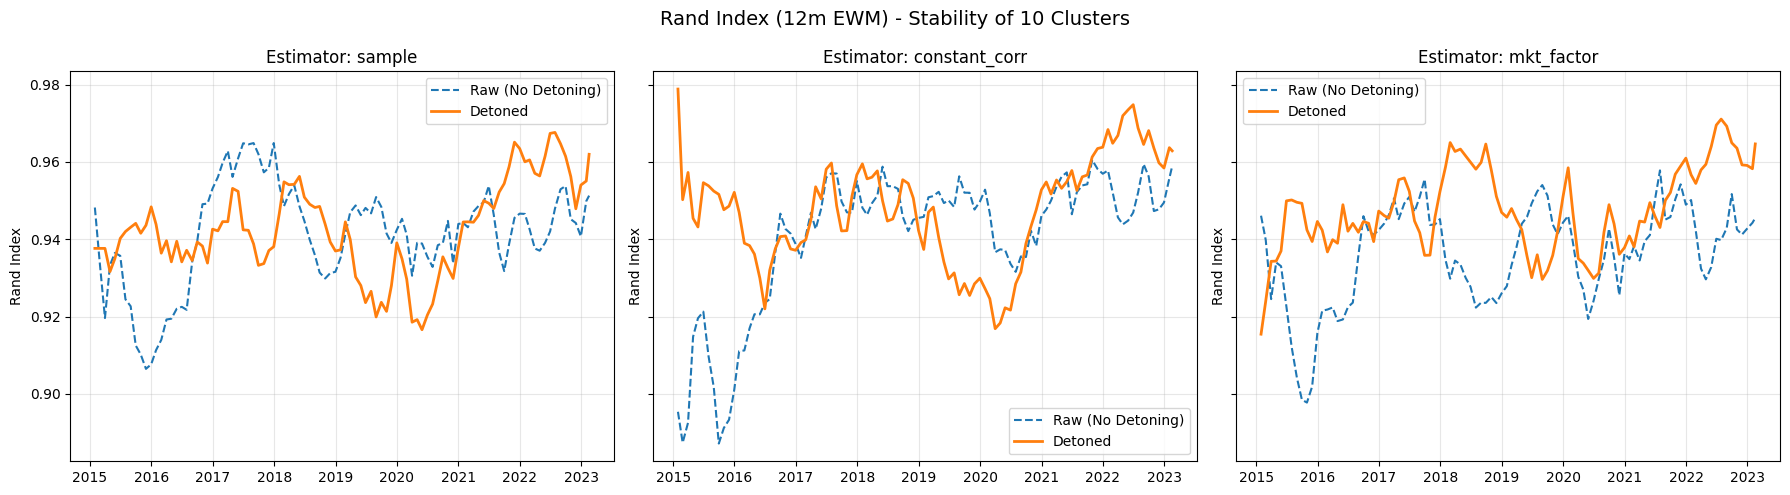

In [ ]:
LINKAGE_METHOD = "ward"
DIST_METRIC = "euclidean"
N_CLUSTERS_GRID = [5, 8, 10, 15]
N_CLUSTERS_FOCUS = 10
COV_KEYS = ["sample", "constant_corr", "mkt_factor"]
DETONE_KEYS = [False, True]


linkages = {(c, d): {} for c in COV_KEYS for d in DETONE_KEYS}
clusters = {
    (c, d, k): {} for c in COV_KEYS for d in DETONE_KEYS for k in N_CLUSTERS_GRID
}

for reb in all_dates:
    for cov_key in COV_KEYS:
        cov = covariances[reb][cov_key]
        for detone_flag in DETONE_KEYS:
            # From covariance to correlation
            corr = covariance_to_correlation(cov.values)
            # Detoning (remove first PC)
            if detone_flag:
                corr = detone(corr, components_num=1)
            # From correlation to distance
            dist = correlation_to_hrp_distance(corr)
            dist_df = pd.DataFrame(dist, index=cov.index, columns=cov.columns)
            # Linkage computation
            link = hierarchical_clustering(
                matrix=dist_df,
                linkage_method=LINKAGE_METHOD,
                distance_metric=DIST_METRIC,
                plot_dendrogram=False
            )
            linkages[(cov_key, detone_flag)][reb] = link
            for n_clusters in N_CLUSTERS_GRID:
                clusters[(cov_key, detone_flag, n_clusters)][reb] = pd.Series(
                    sch.cut_tree(link.values, n_clusters=n_clusters).flatten(),
                    index=cov.index,
                )

rand_indices = {(c, d, k): pd.Series(dtype=float) for c in COV_KEYS for d in DETONE_KEYS for k in N_CLUSTERS_GRID}

for c in COV_KEYS:
    for d in DETONE_KEYS:
        for k in N_CLUSTERS_GRID:
            # we compare the month with the previous one, so we start from the second
            for i in range(1, len(all_dates)):
                prev_date = all_dates[i-1]
                curr_date = all_dates[i]
                
                prev_clusters = clusters[(c, d, k)][prev_date]
                curr_clusters = clusters[(c, d, k)][curr_date]
                
                # score only on the assets present in both months
                common_assets = prev_clusters.index.intersection(curr_clusters.index)
                
                if len(common_assets) > 0:
                    score = rand_score(prev_clusters[common_assets], curr_clusters[common_assets])
                    rand_indices[(c, d, k)].loc[curr_date] = score

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle(f"Rand Index (12m EWM) - Stability of {N_CLUSTERS_FOCUS} Clusters", fontsize=14)

for i, cov_key in enumerate(COV_KEYS):
    ax = axes[i]
    
    ts_no_detone = rand_indices[(cov_key, False, N_CLUSTERS_FOCUS)]
    ts_detone = rand_indices[(cov_key, True, N_CLUSTERS_FOCUS)]
    
    # exponential smoothing
    ax.plot(ts_no_detone.ewm(span=12).mean(), label="Raw (No Detoning)", linestyle="--")
    ax.plot(ts_detone.ewm(span=12).mean(), label="Detoned", linewidth=2)
    
    ax.set_title(f"Estimator: {cov_key}")
    ax.set_ylabel("Rand Index")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 2.d Sensitivity of HRP weights — clustering vs. allocation traversal


In [ ]:
LINK_GRID = ["single", "ward", "complete", "average"]
ALLOC_GRID = {
    "recursive_bisection": recursive_bisection,
    "dendrogram_iteration": dendrogram_iteration,
}

hrp_grid = {}
for cov_key in COV_KEYS:
    for link in LINK_GRID:
        for alloc_name, alloc in ALLOC_GRID.items():
            for d in DETONE_KEYS:
                # weights on each rebalance date
                weights_ts = {}
                for reb in all_dates:
                    cov = covariances[reb][cov_key]
                    
                    w = hierarchical_risk_parity(
                        covariance=cov,
                        linkage_method=link,
                        distance_metric="euclidean", 
                        cluster_traverser=alloc,
                        perform_detoning=d,
                        plot_dendrogram=False
                    )
                    weights_ts[reb] = w

                # Historical series of weights (Date x Tickers)
                hrp_grid[(cov_key, link, alloc_name, d)] = pd.DataFrame(weights_ts).T


summary_list = []
for (cov_key, link, alloc_name, d), weights_df in hrp_grid.items():
    # HHI (Herfindahl-Hirschman Index)
    mean_hhi = (weights_df ** 2).sum(axis=1).mean()
    
    # Turnover: sum of the absolute variations of the weights between consecutive rebalances
    mean_turnover = weights_df.diff().abs().sum(axis=1).mean() / 2.0
    
    summary_list.append({
        "Estimator": cov_key,
        "Linkage": link,
        "Allocator": alloc_name,
        "Detoning": d,
        "Mean HHI": mean_hhi,
        "Mean Turnover": mean_turnover
    })

summary_df = pd.DataFrame(summary_list)
display(summary_df.sort_values(by="Mean HHI"))

/Users/marcogretter/Desktop/poli/FINENG/labs/RM/BS-Assignment-4b/utilities/hierarchical_clustering.py:33: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = sch.linkage(
/Users/marcogretter/Desktop/poli/FINENG/labs/RM/BS-Assignment-4b/utilities/hierarchical_clustering.py:33: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = sch.linkage(
/Users/marcogretter/Desktop/poli/FINENG/labs/RM/BS-Assignment-4b/utilities/hierarchical_clustering.py:33: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = sch.linkage(
/Users/marcogretter/Desktop/poli/FINENG/labs/RM/BS-Assignment-4b/utilities/hierarchical_clustering.py:33: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed 

,Estimator,Linkage,Allocator,Detoning,Mean HHI,Mean Turnover
25,constant_corr,complete,recursive_bisection,True,0.026070,0.108603
21,constant_corr,ward,recursive_bisection,True,0.026094,0.101585
17,constant_corr,single,recursive_bisection,True,0.026123,0.114042
29,constant_corr,average,recursive_bisection,True,0.026234,0.100450
5,sample,ward,recursive_bisection,True,0.026429,0.105859
28,constant_corr,average,recursive_bisection,False,0.026479,0.100925
33,mkt_factor,single,recursive_bisection,True,0.026568,0.115820
37,mkt_factor,ward,recursive_bisection,True,0.026575,0.104573
41,mkt_factor,complete,recursive_bisection,True,0.026583,0.117157
13,sample,average,recursive_bisection,True,0.026598,0.108435


## Part III — Connecting the Dots


### 3.a ERC vs HRP — Robustness Against Estimator Choice

In [ ]:
# HRP strategy
REP_LINKAGE = "ward"
REP_ALLOCATOR = recursive_bisection
REP_DETONING = True

print(f"HRP Setup: {REP_LINKAGE} + {REP_ALLOCATOR.__name__} + Detoning={REP_DETONING}")

# Save weights just computed in a dictionary
weights_store = {
    "HRP": {c: {} for c in COV_KEYS},
    "ERC": {c: {} for c in COV_KEYS}
}

# Weights for all dates and estimators
for reb in all_dates:
    for cov_key in COV_KEYS:
        cov_df = covariances[reb][cov_key]
        
        # HRP weights
        w_hrp = hierarchical_risk_parity(
            covariance=cov_df,
            linkage_method=REP_LINKAGE,
            distance_metric="euclidean",
            cluster_traverser=REP_ALLOCATOR,
            perform_detoning=REP_DETONING,
            plot_dendrogram=False
        )
        weights_store["HRP"][cov_key][reb] = w_hrp
        
        # ERC weights
        # ERC optimizator
        w_erc_np = equal_risk_contribution_portfolio(covariance=cov_df.values)
        w_erc = pd.Series(w_erc_np, index=cov_df.index)
        weights_store["ERC"][cov_key][reb] = w_erc

# from dictionaries to dataframes
for strat in ["HRP", "ERC"]:
    for cov_key in COV_KEYS:
        weights_store[strat][cov_key] = pd.DataFrame(weights_store[strat][cov_key]).T

# Compute L1 distance
estimator_pairs = [
    ("sample", "constant_corr"),
    ("sample", "mkt_factor"),
    ("constant_corr", "mkt_factor")
]

l1_results = []

for strat in ["HRP", "ERC"]:
    for est1, est2 in estimator_pairs:
        w1 = weights_store[strat][est1]
        w2 = weights_store[strat][est2]
        
        # Formula: (1/T) * Σ_t ( Σ_i |w1_{i,t} - w2_{i,t}| )
        avg_l1_dist = (w1 - w2).abs().sum(axis=1).mean()
        
        l1_results.append({
            "Strategy": strat,
            "Comparison": f"{est1} vs {est2}",
            "Avg L1 Distance": avg_l1_dist
        })

# Results
l1_df = pd.DataFrame(l1_results)
l1_pivot = l1_df.pivot(index="Comparison", columns="Strategy", values="Avg L1 Distance")

print("\nResults Distance L1")
display(l1_pivot)

hrp_mean_l1 = l1_pivot["HRP"].mean()
erc_mean_l1 = l1_pivot["ERC"].mean()

print(f"Average L1 Distance HRP: {hrp_mean_l1:.4f}")
print(f"Average L1 Distance ERC: {erc_mean_l1:.4f}")

HRP Setup: ward + recursive_bisection + Detoning=True


/Users/marcogretter/Desktop/poli/FINENG/labs/RM/BS-Assignment-4b/utilities/hierarchical_clustering.py:33: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = sch.linkage(
/Users/marcogretter/Desktop/poli/FINENG/labs/RM/BS-Assignment-4b/utilities/hierarchical_clustering.py:33: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = sch.linkage(
/Users/marcogretter/Desktop/poli/FINENG/labs/RM/BS-Assignment-4b/utilities/hierarchical_clustering.py:33: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = sch.linkage(
/Users/marcogretter/Desktop/poli/FINENG/labs/RM/BS-Assignment-4b/utilities/hierarchical_clustering.py:33: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed 


Results Distance L1


/Users/marcogretter/Desktop/poli/FINENG/labs/RM/BS-Assignment-4b/utilities/hierarchical_clustering.py:33: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = sch.linkage(
/Users/marcogretter/Desktop/poli/FINENG/labs/RM/BS-Assignment-4b/utilities/hierarchical_clustering.py:33: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = sch.linkage(


Strategy,ERC,HRP
Comparison,,
constant_corr vs mkt_factor,0.031900,0.160131
sample vs constant_corr,0.031910,0.165750
sample vs mkt_factor,0.002955,0.108212


Average L1 Distance HRP: 0.1447
Average L1 Distance ERC: 0.0223


### 3.b ERC vs HRP — performance, vol, drawdown, turnover


--- Performance Summary ---


,ERC,HRP
Ann. Return,8.89%,8.16%
Ann. Volatility,18.68%,18.13%
Max Drawdown,-38.36%,-37.56%
Mean Turnover (per rebalance),2.01%,21.17%


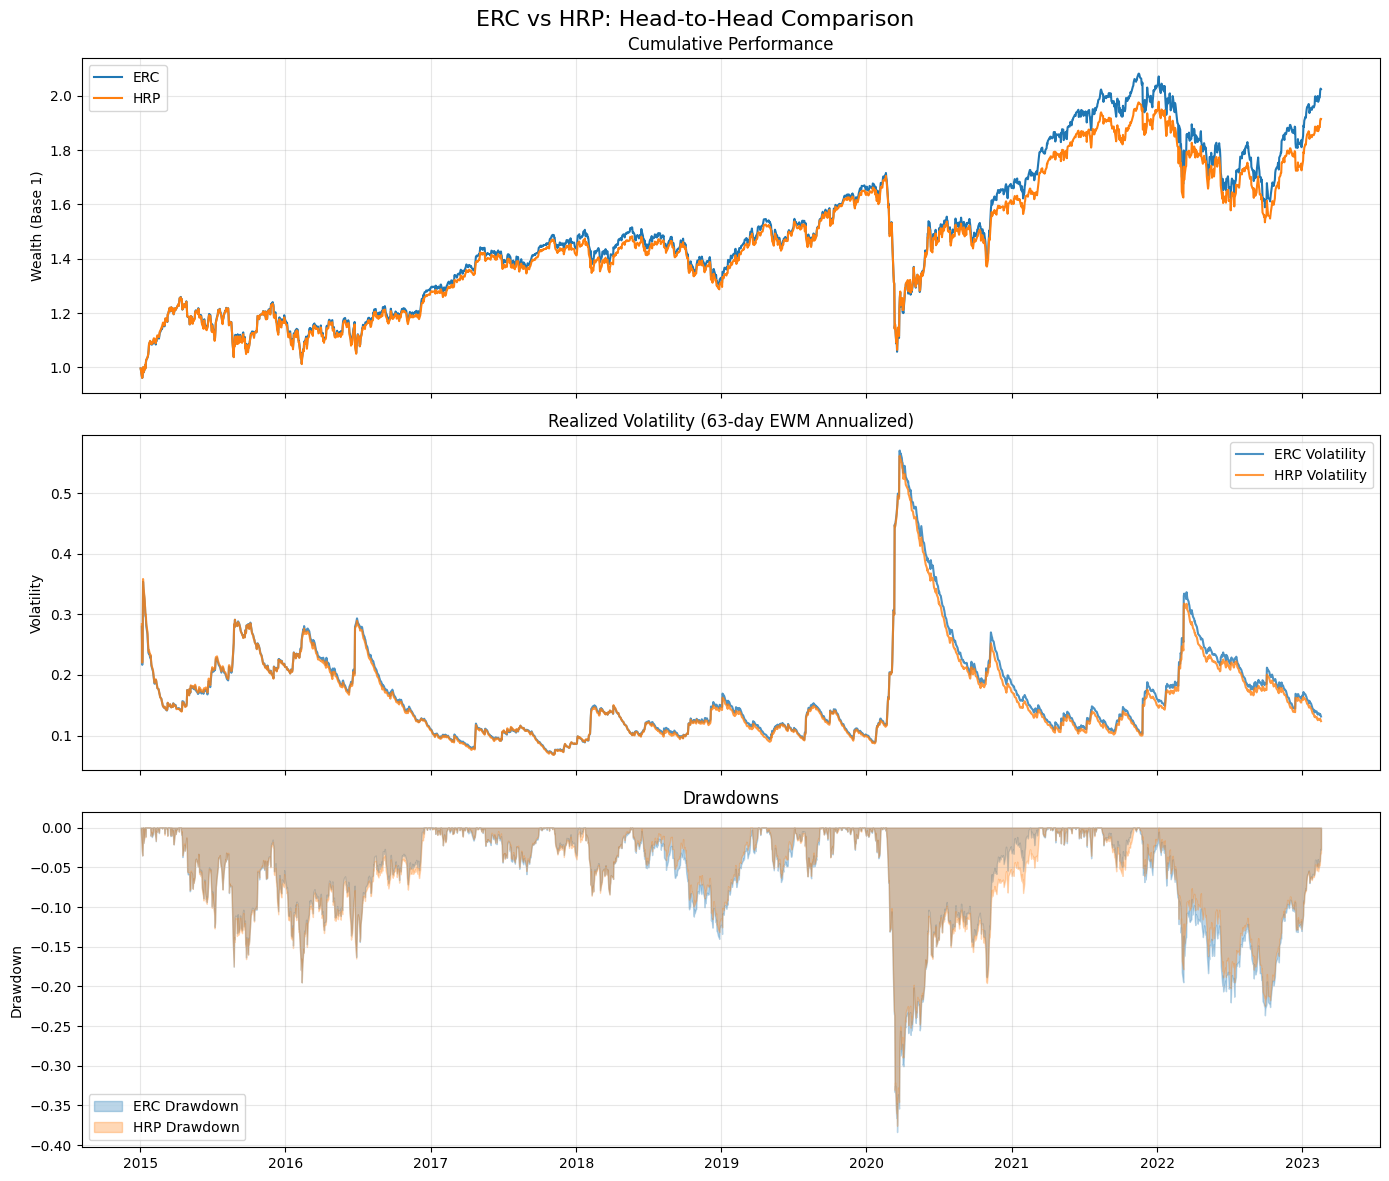

In [ ]:
# Selection of ptfs
CHOSEN_EST = "sample"

w_hrp = weights_store["HRP"][CHOSEN_EST]
w_erc = weights_store["ERC"][CHOSEN_EST]

# Daily returns computation
ret_hrp = portfolio_returns(portfolios=w_hrp, returns=performance, transaction_costs=0.0)
ret_erc = portfolio_returns(portfolios=w_erc, returns=performance, transaction_costs=0.0)

# Cleaning the returns
ret_hrp = ret_hrp.dropna()
ret_erc = ret_erc.dropna()

# Cumulative Performance
cum_hrp = ret_hrp.add(1).cumprod()
cum_erc = ret_erc.add(1).cumprod()

# Realized Volatility (63d EWM annualized)
vol_hrp = ret_hrp.ewm(span=63).std() * np.sqrt(252)
vol_erc = ret_erc.ewm(span=63).std() * np.sqrt(252)

# Drawdowns
dd_hrp = (cum_hrp / cum_hrp.cummax()) - 1
dd_erc = (cum_erc / cum_erc.cummax()) - 1

# Mean Turnover
turnover_hrp = w_hrp.diff().abs().sum(axis=1).mean()
turnover_erc = w_erc.diff().abs().sum(axis=1).mean()

# Results
trading_days = len(ret_hrp)
ann_ret_hrp = (cum_hrp.iloc[-1]) ** (252 / trading_days) - 1
ann_ret_erc = (cum_erc.iloc[-1]) ** (252 / trading_days) - 1

stats_df = pd.DataFrame({
    "ERC": [ann_ret_erc, ret_erc.std() * np.sqrt(252), dd_erc.min(), turnover_erc],
    "HRP": [ann_ret_hrp, ret_hrp.std() * np.sqrt(252), dd_hrp.min(), turnover_hrp]
}, index=["Ann. Return", "Ann. Volatility", "Max Drawdown", "Mean Turnover (per rebalance)"])

print("--- Performance Summary ---")
display(stats_df.style.format("{:.2%}"))


fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.suptitle("ERC vs HRP: Head-to-Head Comparison", fontsize=16)

# Plot of Cumulative Performance
axes[0].plot(cum_erc, label="ERC", color="tab:blue")
axes[0].plot(cum_hrp, label="HRP", color="tab:orange")
axes[0].set_title("Cumulative Performance")
axes[0].set_ylabel("Wealth (Base 1)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot of Realized Volatility (63d EWM)
axes[1].plot(vol_erc, label="ERC Volatility", color="tab:blue", alpha=0.8)
axes[1].plot(vol_hrp, label="HRP Volatility", color="tab:orange", alpha=0.8)
axes[1].set_title("Realized Volatility (63-day EWM Annualized)")
axes[1].set_ylabel("Volatility")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot of Drawdowns
axes[2].fill_between(dd_erc.index, dd_erc, 0, label="ERC Drawdown", color="tab:blue", alpha=0.3)
axes[2].fill_between(dd_hrp.index, dd_hrp, 0, label="HRP Drawdown", color="tab:orange", alpha=0.3)
axes[2].set_title("Drawdowns")
axes[2].set_ylabel("Drawdown")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()